<a href="https://colab.research.google.com/github/pietraprds/Atividade-avaliativa-de-Logica-de-Programacao/blob/main/AdminAn%C3%A1liseA%C3%A7%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise do Código de Referência - Petrobrás (PETR4)

## Visão Geral

Este código implementa uma análise financeira completa da ação da Petrobrás (PETR4.SA) para o período de **janeiro de 2023 a maio de 2026**. O script demonstra todas as etapas necessárias para baixar, processar, analisar e visualizar dados históricos de ações, servindo como referência para a análise das demais empresas.



📥 Baixando dados da PETR4.SA de 2023-01-01 até 2026-05-14...
✅ Dados carregados! Shape: (838, 5)
Colunas disponíveis: [('Close', 'PETR4.SA'), ('High', 'PETR4.SA'), ('Low', 'PETR4.SA'), ('Open', 'PETR4.SA'), ('Volume', 'PETR4.SA')]
Período: 2023-01-02 até 2026-05-13

📋 5 PRIMEIRAS LINHAS
            Abertura  Máxima  Mínima  Fechamento     Volume
Date                                                       
2023-01-02     12.80   13.30   12.73       13.15   78424700
2023-01-03     12.48   12.90   12.36       12.81   96750300
2023-01-04     12.87   13.17   12.19       12.26  129504000
2023-01-05     13.34   13.43   12.93       13.04   73886000
2023-01-06     13.26   13.58   13.15       13.37   51851500

📋 5 ÚLTIMAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2026-05-07     46.22   46.65   45.20       46.40  71214500
2026-05-08     45.67   46.55   45.67       46.39  32914200
2026-05-11     46.43   46.51   45.65

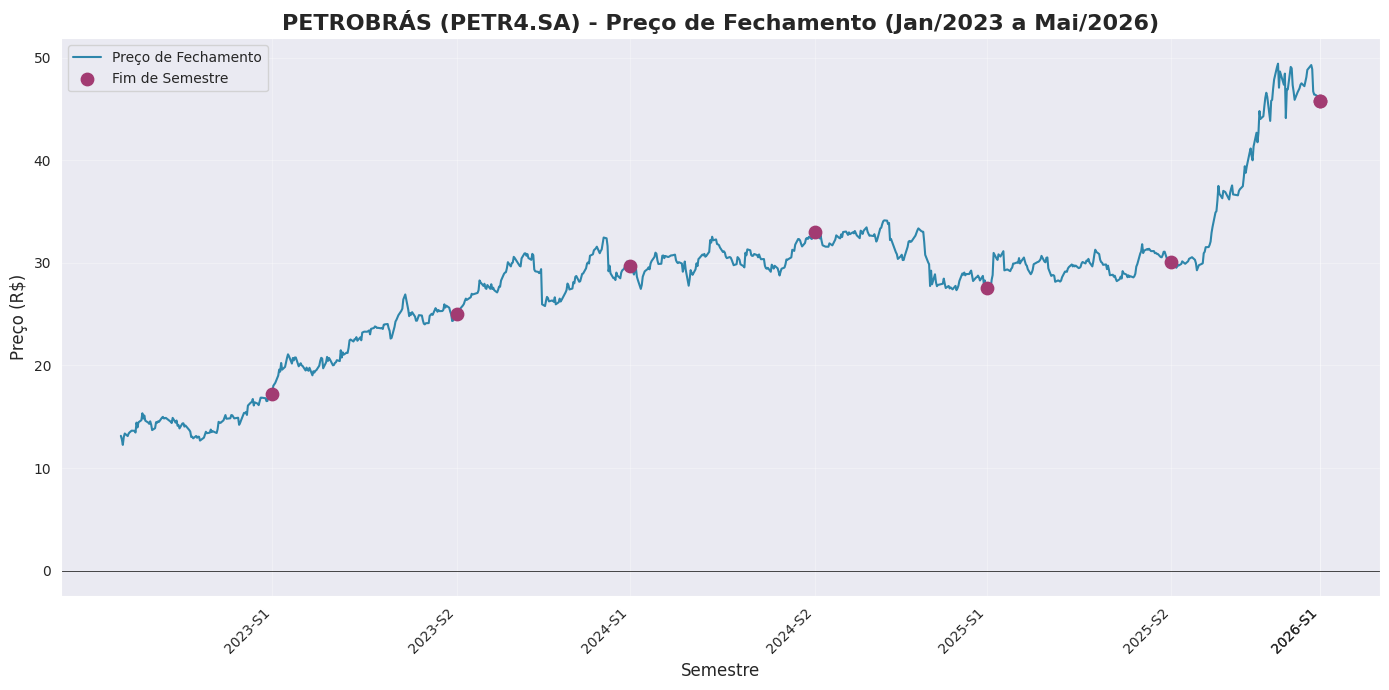


📊 TABELA RESUMO SEMESTRAL
 Ano Semestre  Abertura_R$  Fechamento_R$  Média_R$  Desvio_R$  Mínimo_R$  Máximo_R$  Retorno_%
2023       S1        13.15          20.78     15.29       2.21      12.26      21.09      58.06
2023       S2        19.92          26.92     23.22       2.25      19.04      26.99      35.14
2024       S1        27.07          30.17     28.85       1.54      25.79      32.47      11.44
2024       S2        30.58          31.71     30.72       1.10      27.78      33.12       3.69
2025       S1        32.27          29.19     30.72       2.17      27.33      34.14      -9.54
2025       S2        29.42          30.40     29.81       0.85      28.16      31.82       3.32
2026       S1        30.55          45.77     40.99       6.39      29.28      49.41      49.80

🎉 ANÁLISE CONCLUÍDA COM SUCESSO!

📈 RESUMO FINAL DO PERÍODO
Preço Inicial (jan/2023): R$ 13.15
Preço Final (mai/2026): R$ 45.77
Retorno Total no período: +248.14%
Volume Médio Diário: 43,917,718 ações


In [ ]:
# =====================================================
# ANÁLISE DA PETROBRÁS (PETR4) - JAN/2023 ATÉ MAI/2026
# =====================================================

!pip install yfinance pandas matplotlib seaborn -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

# ================== 1. BAIXAR DADOS ==================
ticker = "PETR4.SA"
start_date = "2023-01-01"
end_date = "2026-05-14"

print(f"📥 Baixando dados da {ticker} de {start_date} até {end_date}...")

df_petro = yf.download(ticker, start=start_date, end=end_date, progress=False)

print(f"✅ Dados carregados! Shape: {df_petro.shape}")
print(f"Colunas disponíveis: {list(df_petro.columns)}")

# Renomear colunas para português (apenas 5 colunas)
df_petro.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']

print(f"Período: {df_petro.index.min().date()} até {df_petro.index.max().date()}")

# ================== 2. 5 PRIMEIRAS E 5 ÚLTIMAS LINHAS ==================
print("\n" + "="*80)
print("📋 5 PRIMEIRAS LINHAS")
print("="*80)
print(df_petro[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].head().round(2))

print("\n" + "="*80)
print("📋 5 ÚLTIMAS LINHAS")
print("="*80)
print(df_petro[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].tail().round(2))

# ================== 3. MÉDIA ANUAL DO PREÇO DE FECHAMENTO ==================
df_petro['Ano'] = df_petro.index.year
media_anual = df_petro.groupby('Ano')['Fechamento'].mean()

print("\n" + "="*80)
print("📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, media in media_anual.items():
    print(f"{ano}: R$ {media:.2f}")

# ================== 4. DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO ==================
std_anual = df_petro.groupby('Ano')['Fechamento'].std()

print("\n" + "="*80)
print("📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, std in std_anual.items():
    print(f"{ano}: R$ {std:.2f}")

# ================== 5. RETORNO SEMESTRAL ==================
# Adicionar coluna de semestre
df_petro['Semestre'] = df_petro.index.quarter.map({1: 'S1', 2: 'S1', 3: 'S2', 4: 'S2'})
df_petro['Ano_Semestre'] = df_petro['Ano'].astype(str) + '_' + df_petro['Semestre']

# Calcular retorno semestral (primeiro vs último dia de cada semestre)
print("\n" + "="*80)
print("📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (%)")
print("="*80)

# Obter último dia de cada semestre
ultimo_dia_semestre = df_petro.groupby('Ano_Semestre').apply(lambda x: x.index.max())
retornos_semestrais = []

for i in range(len(ultimo_dia_semestre) - 1):
    sem_atual = ultimo_dia_semestre.index[i]
    sem_seguinte = ultimo_dia_semestre.index[i+1]

    fechamento_atual = df_petro.loc[ultimo_dia_semestre[i], 'Fechamento']
    fechamento_seguinte = df_petro.loc[ultimo_dia_semestre[i+1], 'Fechamento']

    retorno = ((fechamento_seguinte - fechamento_atual) / fechamento_atual) * 100
    sinal = "+" if retorno >= 0 else ""
    print(f"{sem_atual} → {sem_seguinte}: {sinal}{retorno:.2f}%")

    retornos_semestrais.append({
        'Período': f"{sem_atual} → {sem_seguinte}",
        'Retorno_%': retorno
    })

# ================== 6. GRÁFICO DE LINHA COM EIXO X SEMESTRAL ==================
# Criar pontos para cada semestre (último dia útil de cada semestre)
pontos_semestrais = []
labels_semestrais = []

# Definir os meses de fim de semestre: Junho (S1) e Dezembro (S2)
for ano in range(2023, 2027):
    for sem, mes in [('S1', 6), ('S2', 12)]:
        try:
            # Tentar pegar o último dia do mês (junho ou dezembro)
            data_alvo = pd.Timestamp(f"{ano}-{mes}-{mes}")
            # Buscar o maior índice <= data_alvo
            dados_semestre = df_petro[df_petro.index <= data_alvo]
            if not dados_semestre.empty:
                ultima_data = dados_semestre.index[-1]
                pontos_semestrais.append(ultima_data)
                labels_semestrais.append(f"{ano}-{sem}")
        except:
            pass

# Filtrar apenas pontos até maio/2026
pontos_semestrais = [p for p in pontos_semestrais if p <= pd.Timestamp("2026-05-14")]

# Criar o gráfico
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_petro.index, df_petro['Fechamento'], linewidth=1.5, color='#2E86AB', label='Preço de Fechamento')

# Destacar pontos semestrais
if pontos_semestrais:
    valores_semestrais = df_petro.loc[pontos_semestrais, 'Fechamento']
    ax.scatter(pontos_semestrais, valores_semestrais, color='#A23B72', s=80, zorder=5, label='Fim de Semestre')

# Configurar eixo X com semestres
if pontos_semestrais:
    ax.set_xticks(pontos_semestrais)
    ax.set_xticklabels([f"{p.year}-{'S1' if p.month <= 6 else 'S2'}" for p in pontos_semestrais],
                       rotation=45, ha='right')

ax.set_title('PETROBRÁS (PETR4.SA) - Preço de Fechamento (Jan/2023 a Mai/2026)', fontsize=16, fontweight='bold')
ax.set_xlabel('Semestre', fontsize=12)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# ================== 7. TABELA RESUMO SEMESTRAL ==================
print("\n" + "="*80)
print("📊 TABELA RESUMO SEMESTRAL")
print("="*80)

# Função para obter último dia de cada semestre
def get_ultimo_dia_semestre(df, ano, semestre):
    if semestre == 'S1':
        data_fim = pd.Timestamp(f"{ano}-06-30")
    else:
        data_fim = pd.Timestamp(f"{ano}-12-31")

    dados_sem = df[df.index <= data_fim]
    if not dados_sem.empty:
        ultima_data = dados_sem.index[-1]
        return ultima_data
    return None

tabela_semestral = []
for ano in range(2023, 2027):
    for sem in ['S1', 'S2']:
        ultima_data = get_ultimo_dia_semestre(df_petro, ano, sem)
        if ultima_data and ultima_data <= pd.Timestamp("2026-05-14"):
            dados_sem = df_petro[df_petro.index.year == ano]
            if sem == 'S1':
                dados_sem = dados_sem[dados_sem.index.month <= 6]
            else:
                dados_sem = dados_sem[dados_sem.index.month > 6]

            if not dados_sem.empty:
                abertura = dados_sem['Fechamento'].iloc[0]
                fechamento = dados_sem['Fechamento'].iloc[-1]
                media = dados_sem['Fechamento'].mean()
                desvio = dados_sem['Fechamento'].std()
                minimo = dados_sem['Fechamento'].min()
                maximo = dados_sem['Fechamento'].max()
                retorno = ((fechamento - abertura) / abertura) * 100

                tabela_semestral.append({
                    'Ano': ano,
                    'Semestre': sem,
                    'Abertura_R$': abertura,
                    'Fechamento_R$': fechamento,
                    'Média_R$': media,
                    'Desvio_R$': desvio,
                    'Mínimo_R$': minimo,
                    'Máximo_R$': maximo,
                    'Retorno_%': retorno
                })

df_tabela = pd.DataFrame(tabela_semestral)
print(df_tabela.to_string(index=False, float_format="%.2f"))

print("\n" + "="*80)
print("🎉 ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*80)

# Estatísticas adicionais finais
print("\n" + "="*80)
print("📈 RESUMO FINAL DO PERÍODO")
print("="*80)
preco_inicial = df_petro['Fechamento'].iloc[0]
preco_final = df_petro['Fechamento'].iloc[-1]
retorno_total = ((preco_final - preco_inicial) / preco_inicial) * 100
print(f"Preço Inicial (jan/2023): R$ {preco_inicial:.2f}")
print(f"Preço Final (mai/2026): R$ {preco_final:.2f}")
print(f"Retorno Total no período: {retorno_total:+.2f}%")
print(f"Volume Médio Diário: {df_petro['Volume'].mean():,.0f} ações")

1) Banco do Brasil

📥 Baixando dados da BBAS3.SA de 2023-01-01 até 2026-05-14...
✅ Dados carregados! Shape: (838, 5)
Colunas disponíveis: [('Close', 'BBAS3.SA'), ('High', 'BBAS3.SA'), ('Low', 'BBAS3.SA'), ('Open', 'BBAS3.SA'), ('Volume', 'BBAS3.SA')]
Período: 2023-01-02 até 2026-05-13

📋 5 PRIMEIRAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2023-01-02     12.92   13.29   12.78       13.29  23557000
2023-01-03     12.68   12.97   12.59       12.92  21547400
2023-01-04     12.84   12.92   12.65       12.75  19519000
2023-01-05     13.43   13.49   12.85       12.93  33937600
2023-01-06     13.61   13.70   13.38       13.46  29504600

📋 5 ÚLTIMAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2026-05-07     21.69   22.12   21.69       22.06  19233100
2026-05-08     21.80   22.17   21.75       21.91  22432400
2026-05-11     21.54   21.85   21.54       

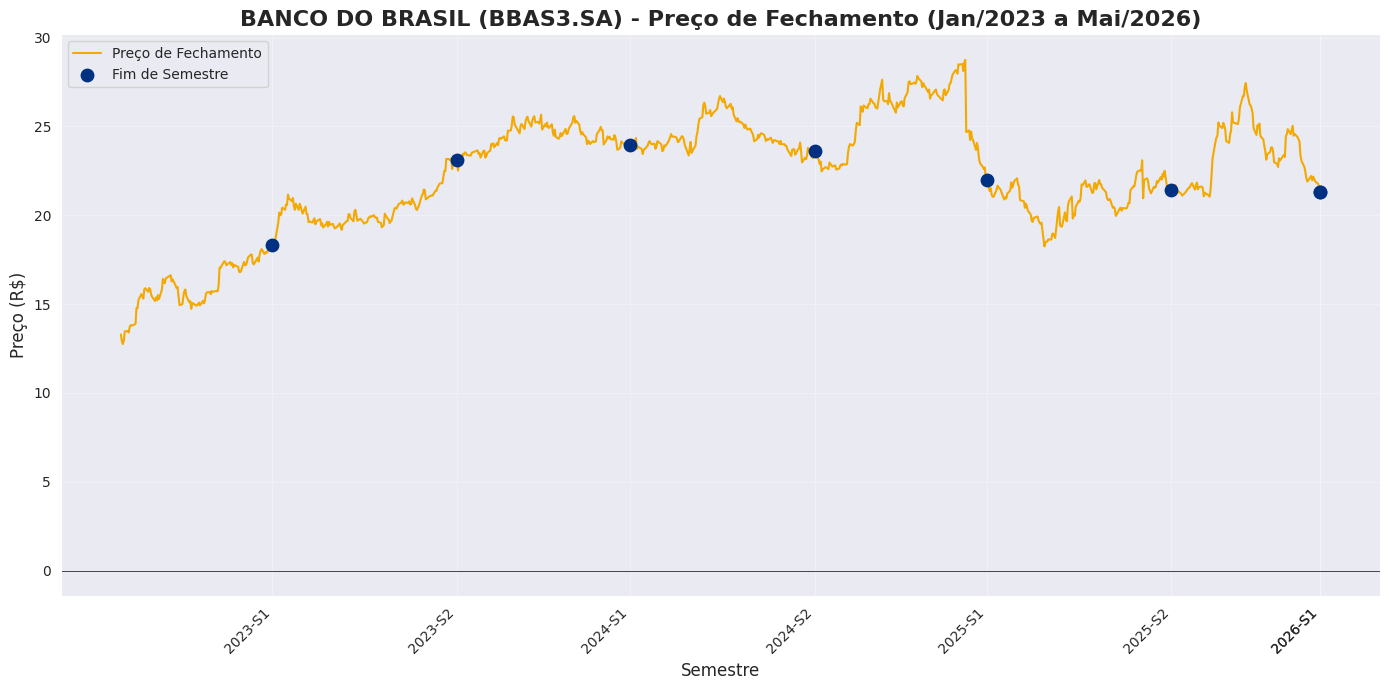


📊 TABELA RESUMO SEMESTRAL
 Ano Semestre  Abertura_R$  Fechamento_R$  Média_R$  Desvio_R$  Mínimo_R$  Máximo_R$  Retorno_%
2023       S1        13.29          20.65     16.55       1.95      12.75      21.16      55.38
2023       S2        20.31          23.54     20.65       1.29      19.18      23.54      15.92
2024       S1        23.65          24.00     24.46       0.60      23.25      25.66       1.44
2024       S2        24.03          22.74     24.44       1.01      22.47      26.71      -5.36
2025       S1        22.81          21.39     25.31       2.27      20.89      28.75      -6.22
2025       S2        21.85          21.53     20.88       1.04      18.24      23.09      -1.46
2026       S1        21.81          21.33     23.75       1.65      21.05      27.45      -2.21

🎉 ANÁLISE CONCLUÍDA COM SUCESSO!

📈 RESUMO FINAL DO PERÍODO
Preço Inicial (jan/2023): R$ 13.29
Preço Final (mai/2026): R$ 21.33
Retorno Total no período: +60.47%
Volume Médio Diário: 23,584,126 ações


In [1]:
# =====================================================
# ANÁLISE DO BANCO DO BRASIL (BBAS3) - JAN/2023 ATÉ MAI/2026
# =====================================================

!pip install yfinance pandas matplotlib seaborn -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

# ================== 1. BAIXAR DADOS ==================
ticker = "BBAS3.SA"
start_date = "2023-01-01"
end_date = "2026-05-14"

print(f"📥 Baixando dados da {ticker} de {start_date} até {end_date}...")

df_bb = yf.download(ticker, start=start_date, end=end_date, progress=False)

print(f"✅ Dados carregados! Shape: {df_bb.shape}")
print(f"Colunas disponíveis: {list(df_bb.columns)}")

df_bb.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']

print(f"Período: {df_bb.index.min().date()} até {df_bb.index.max().date()}")

# ================== 2. 5 PRIMEIRAS E 5 ÚLTIMAS LINHAS ==================
print("\n" + "="*80)
print("📋 5 PRIMEIRAS LINHAS")
print("="*80)
print(df_bb[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].head().round(2))

print("\n" + "="*80)
print("📋 5 ÚLTIMAS LINHAS")
print("="*80)
print(df_bb[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].tail().round(2))

# ================== 3. MÉDIA ANUAL DO PREÇO DE FECHAMENTO ==================
df_bb['Ano'] = df_bb.index.year
media_anual = df_bb.groupby('Ano')['Fechamento'].mean()

print("\n" + "="*80)
print("📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, media in media_anual.items():
    print(f"{ano}: R$ {media:.2f}")

# ================== 4. DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO ==================
std_anual = df_bb.groupby('Ano')['Fechamento'].std()

print("\n" + "="*80)
print("📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, std in std_anual.items():
    print(f"{ano}: R$ {std:.2f}")

# ================== 5. RETORNO SEMESTRAL ==================
df_bb['Semestre'] = df_bb.index.quarter.map({1: 'S1', 2: 'S1', 3: 'S2', 4: 'S2'})
df_bb['Ano_Semestre'] = df_bb['Ano'].astype(str) + '_' + df_bb['Semestre']

print("\n" + "="*80)
print("📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (%)")
print("="*80)

ultimo_dia_semestre = df_bb.groupby('Ano_Semestre').apply(lambda x: x.index.max())
retornos_semestrais = []

for i in range(len(ultimo_dia_semestre) - 1):
    sem_atual = ultimo_dia_semestre.index[i]
    sem_seguinte = ultimo_dia_semestre.index[i+1]

    fechamento_atual = df_bb.loc[ultimo_dia_semestre[i], 'Fechamento']
    fechamento_seguinte = df_bb.loc[ultimo_dia_semestre[i+1], 'Fechamento']

    retorno = ((fechamento_seguinte - fechamento_atual) / fechamento_atual) * 100
    sinal = "+" if retorno >= 0 else ""
    print(f"{sem_atual} → {sem_seguinte}: {sinal}{retorno:.2f}%")

    retornos_semestrais.append({
        'Período': f"{sem_atual} → {sem_seguinte}",
        'Retorno_%': retorno
    })

# ================== 6. GRÁFICO DE LINHA COM EIXO X SEMESTRAL ==================
pontos_semestrais = []
labels_semestrais = []

for ano in range(2023, 2027):
    for sem, mes in [('S1', 6), ('S2', 12)]:
        try:
            data_alvo = pd.Timestamp(f"{ano}-{mes}-{mes}")
            dados_semestre = df_bb[df_bb.index <= data_alvo]
            if not dados_semestre.empty:
                ultima_data = dados_semestre.index[-1]
                pontos_semestrais.append(ultima_data)
                labels_semestrais.append(f"{ano}-{sem}")
        except:
            pass

pontos_semestrais = [p for p in pontos_semestrais if p <= pd.Timestamp("2026-05-14")]

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_bb.index, df_bb['Fechamento'], linewidth=1.5, color='#F4A900', label='Preço de Fechamento')

if pontos_semestrais:
    valores_semestrais = df_bb.loc[pontos_semestrais, 'Fechamento']
    ax.scatter(pontos_semestrais, valores_semestrais, color='#003082', s=80, zorder=5, label='Fim de Semestre')

if pontos_semestrais:
    ax.set_xticks(pontos_semestrais)
    ax.set_xticklabels([f"{p.year}-{'S1' if p.month <= 6 else 'S2'}" for p in pontos_semestrais],
                       rotation=45, ha='right')

ax.set_title('BANCO DO BRASIL (BBAS3.SA) - Preço de Fechamento (Jan/2023 a Mai/2026)', fontsize=16, fontweight='bold')
ax.set_xlabel('Semestre', fontsize=12)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# ================== 7. TABELA RESUMO SEMESTRAL ==================
print("\n" + "="*80)
print("📊 TABELA RESUMO SEMESTRAL")
print("="*80)

def get_ultimo_dia_semestre(df, ano, semestre):
    if semestre == 'S1':
        data_fim = pd.Timestamp(f"{ano}-06-30")
    else:
        data_fim = pd.Timestamp(f"{ano}-12-31")

    dados_sem = df[df.index <= data_fim]
    if not dados_sem.empty:
        ultima_data = dados_sem.index[-1]
        return ultima_data
    return None

tabela_semestral = []
for ano in range(2023, 2027):
    for sem in ['S1', 'S2']:
        ultima_data = get_ultimo_dia_semestre(df_bb, ano, sem)
        if ultima_data and ultima_data <= pd.Timestamp("2026-05-14"):
            dados_sem = df_bb[df_bb.index.year == ano]
            if sem == 'S1':
                dados_sem = dados_sem[dados_sem.index.month <= 6]
            else:
                dados_sem = dados_sem[dados_sem.index.month > 6]

            if not dados_sem.empty:
                abertura = dados_sem['Fechamento'].iloc[0]
                fechamento = dados_sem['Fechamento'].iloc[-1]
                media = dados_sem['Fechamento'].mean()
                desvio = dados_sem['Fechamento'].std()
                minimo = dados_sem['Fechamento'].min()
                maximo = dados_sem['Fechamento'].max()
                retorno = ((fechamento - abertura) / abertura) * 100

                tabela_semestral.append({
                    'Ano': ano,
                    'Semestre': sem,
                    'Abertura_R$': abertura,
                    'Fechamento_R$': fechamento,
                    'Média_R$': media,
                    'Desvio_R$': desvio,
                    'Mínimo_R$': minimo,
                    'Máximo_R$': maximo,
                    'Retorno_%': retorno
                })

df_tabela = pd.DataFrame(tabela_semestral)
print(df_tabela.to_string(index=False, float_format="%.2f"))

print("\n" + "="*80)
print("🎉 ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*80)

print("\n" + "="*80)
print("📈 RESUMO FINAL DO PERÍODO")
print("="*80)
preco_inicial = df_bb['Fechamento'].iloc[0]
preco_final = df_bb['Fechamento'].iloc[-1]
retorno_total = ((preco_final - preco_inicial) / preco_inicial) * 100
print(f"Preço Inicial (jan/2023): R$ {preco_inicial:.2f}")
print(f"Preço Final (mai/2026): R$ {preco_final:.2f}")
print(f"Retorno Total no período: {retorno_total:+.2f}%")
print(f"Volume Médio Diário: {df_bb['Volume'].mean():,.0f} ações")

2) AMBEV

📥 Baixando dados da ABEV3.SA de 2023-01-01 até 2026-05-14...
✅ Dados carregados! Shape: (838, 5)
Colunas disponíveis: [('Close', 'ABEV3.SA'), ('High', 'ABEV3.SA'), ('Low', 'ABEV3.SA'), ('Open', 'ABEV3.SA'), ('Volume', 'ABEV3.SA')]
Período: 2023-01-02 até 2026-05-13

📋 5 PRIMEIRAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2023-01-02     12.00   12.22   11.85       12.17  14995900
2023-01-03     11.98   12.17   11.93       11.97  36363800
2023-01-04     12.05   12.23   11.90       12.07  23791800
2023-01-05     12.08   12.18   11.95       12.06  31031500
2023-01-06     12.11   12.14   11.97       12.09  20889800

📋 5 ÚLTIMAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2026-05-07     16.41   17.04   16.32       16.86  30952400
2026-05-08     16.32   16.55   16.18       16.49  41784100
2026-05-11     16.25   16.50   16.17       

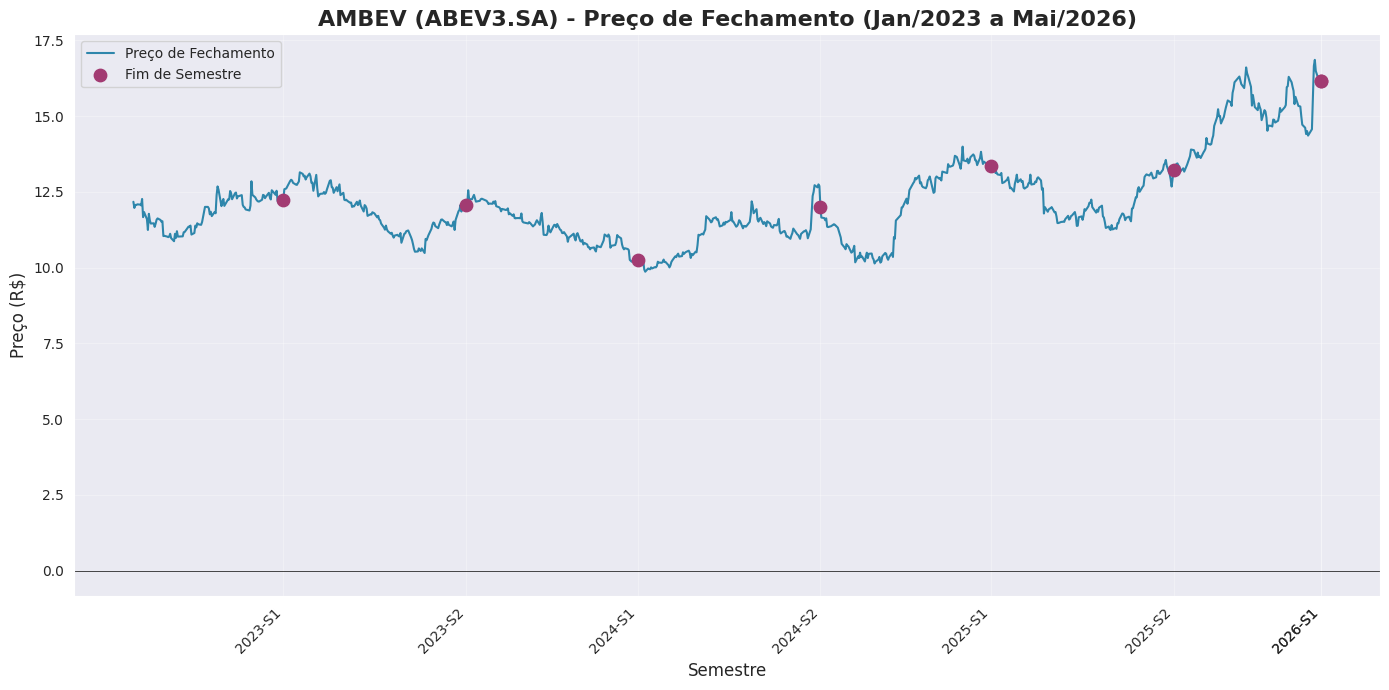


📊 TABELA RESUMO SEMESTRAL
 Ano Semestre  Abertura_R$  Fechamento_R$  Média_R$  Desvio_R$  Mínimo_R$  Máximo_R$  Retorno_%
2023       S1        12.17          12.98     11.99       0.58      10.87      13.15       6.60
2023       S2        13.10          12.28     11.78       0.65      10.48      13.10      -6.31
2024       S1        12.21          10.17     11.07       0.62       9.87      12.21     -16.69
2024       S2        10.16          11.32     11.24       0.58      10.01      12.75      11.42
2025       S1        11.00          12.51     12.18       1.30      10.14      14.00      13.75
2025       S2        12.77          13.90     12.31       0.71      11.24      13.90       8.82
2026       S1        13.88          16.16     15.18       0.80      13.62      16.86      16.43

🎉 ANÁLISE CONCLUÍDA COM SUCESSO!

📈 RESUMO FINAL DO PERÍODO
Preço Inicial (jan/2023): R$ 12.17
Preço Final (mai/2026): R$ 16.16
Retorno Total no período: +32.73%
Volume Médio Diário: 29,107,495 ações


In [2]:
# =====================================================
# ANÁLISE DA AMBEV (ABEV3) - JAN/2023 ATÉ MAI/2026
# =====================================================

!pip install yfinance pandas matplotlib seaborn -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

# ================== 1. BAIXAR DADOS ==================
ticker = "ABEV3.SA"                          # ← alterado
start_date = "2023-01-01"
end_date = "2026-05-14"

print(f"📥 Baixando dados da {ticker} de {start_date} até {end_date}...")

df_ambev = yf.download(ticker, start=start_date, end=end_date, progress=False)

print(f"✅ Dados carregados! Shape: {df_ambev.shape}")
print(f"Colunas disponíveis: {list(df_ambev.columns)}")

# Renomear colunas para português (apenas 5 colunas)
df_ambev.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']

print(f"Período: {df_ambev.index.min().date()} até {df_ambev.index.max().date()}")

# ================== 2. 5 PRIMEIRAS E 5 ÚLTIMAS LINHAS ==================
print("\n" + "="*80)
print("📋 5 PRIMEIRAS LINHAS")
print("="*80)
print(df_ambev[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].head().round(2))

print("\n" + "="*80)
print("📋 5 ÚLTIMAS LINHAS")
print("="*80)
print(df_ambev[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].tail().round(2))

# ================== 3. MÉDIA ANUAL DO PREÇO DE FECHAMENTO ==================
df_ambev['Ano'] = df_ambev.index.year
media_anual = df_ambev.groupby('Ano')['Fechamento'].mean()

print("\n" + "="*80)
print("📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, media in media_anual.items():
    print(f"{ano}: R$ {media:.2f}")

# ================== 4. DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO ==================
std_anual = df_ambev.groupby('Ano')['Fechamento'].std()

print("\n" + "="*80)
print("📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, std in std_anual.items():
    print(f"{ano}: R$ {std:.2f}")

# ================== 5. RETORNO SEMESTRAL ==================
df_ambev['Semestre'] = df_ambev.index.quarter.map({1: 'S1', 2: 'S1', 3: 'S2', 4: 'S2'})
df_ambev['Ano_Semestre'] = df_ambev['Ano'].astype(str) + '_' + df_ambev['Semestre']

print("\n" + "="*80)
print("📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (%)")
print("="*80)

ultimo_dia_semestre = df_ambev.groupby('Ano_Semestre').apply(lambda x: x.index.max())
retornos_semestrais = []

for i in range(len(ultimo_dia_semestre) - 1):
    sem_atual = ultimo_dia_semestre.index[i]
    sem_seguinte = ultimo_dia_semestre.index[i+1]

    fechamento_atual = df_ambev.loc[ultimo_dia_semestre[i], 'Fechamento']
    fechamento_seguinte = df_ambev.loc[ultimo_dia_semestre[i+1], 'Fechamento']

    retorno = ((fechamento_seguinte - fechamento_atual) / fechamento_atual) * 100
    sinal = "+" if retorno >= 0 else ""
    print(f"{sem_atual} → {sem_seguinte}: {sinal}{retorno:.2f}%")

    retornos_semestrais.append({
        'Período': f"{sem_atual} → {sem_seguinte}",
        'Retorno_%': retorno
    })

# ================== 6. GRÁFICO DE LINHA COM EIXO X SEMESTRAL ==================
pontos_semestrais = []
labels_semestrais = []

for ano in range(2023, 2027):
    for sem, mes in [('S1', 6), ('S2', 12)]:
        try:
            data_alvo = pd.Timestamp(f"{ano}-{mes}-{mes}")
            dados_semestre = df_ambev[df_ambev.index <= data_alvo]
            if not dados_semestre.empty:
                ultima_data = dados_semestre.index[-1]
                pontos_semestrais.append(ultima_data)
                labels_semestrais.append(f"{ano}-{sem}")
        except:
            pass

pontos_semestrais = [p for p in pontos_semestrais if p <= pd.Timestamp("2026-05-14")]

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_ambev.index, df_ambev['Fechamento'], linewidth=1.5, color='#2E86AB', label='Preço de Fechamento')

if pontos_semestrais:
    valores_semestrais = df_ambev.loc[pontos_semestrais, 'Fechamento']
    ax.scatter(pontos_semestrais, valores_semestrais, color='#A23B72', s=80, zorder=5, label='Fim de Semestre')

if pontos_semestrais:
    ax.set_xticks(pontos_semestrais)
    ax.set_xticklabels([f"{p.year}-{'S1' if p.month <= 6 else 'S2'}" for p in pontos_semestrais],
                       rotation=45, ha='right')

ax.set_title('AMBEV (ABEV3.SA) - Preço de Fechamento (Jan/2023 a Mai/2026)',   # ← alterado
             fontsize=16, fontweight='bold')
ax.set_xlabel('Semestre', fontsize=12)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# ================== 7. TABELA RESUMO SEMESTRAL ==================
print("\n" + "="*80)
print("📊 TABELA RESUMO SEMESTRAL")
print("="*80)

def get_ultimo_dia_semestre(df, ano, semestre):
    if semestre == 'S1':
        data_fim = pd.Timestamp(f"{ano}-06-30")
    else:
        data_fim = pd.Timestamp(f"{ano}-12-31")

    dados_sem = df[df.index <= data_fim]
    if not dados_sem.empty:
        ultima_data = dados_sem.index[-1]
        return ultima_data
    return None

tabela_semestral = []
for ano in range(2023, 2027):
    for sem in ['S1', 'S2']:
        ultima_data = get_ultimo_dia_semestre(df_ambev, ano, sem)
        if ultima_data and ultima_data <= pd.Timestamp("2026-05-14"):
            dados_sem = df_ambev[df_ambev.index.year == ano]
            if sem == 'S1':
                dados_sem = dados_sem[dados_sem.index.month <= 6]
            else:
                dados_sem = dados_sem[dados_sem.index.month > 6]

            if not dados_sem.empty:
                abertura = dados_sem['Fechamento'].iloc[0]
                fechamento = dados_sem['Fechamento'].iloc[-1]
                media = dados_sem['Fechamento'].mean()
                desvio = dados_sem['Fechamento'].std()
                minimo = dados_sem['Fechamento'].min()
                maximo = dados_sem['Fechamento'].max()
                retorno = ((fechamento - abertura) / abertura) * 100

                tabela_semestral.append({
                    'Ano': ano,
                    'Semestre': sem,
                    'Abertura_R$': abertura,
                    'Fechamento_R$': fechamento,
                    'Média_R$': media,
                    'Desvio_R$': desvio,
                    'Mínimo_R$': minimo,
                    'Máximo_R$': maximo,
                    'Retorno_%': retorno
                })

df_tabela = pd.DataFrame(tabela_semestral)
print(df_tabela.to_string(index=False, float_format="%.2f"))

print("\n" + "="*80)
print("🎉 ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*80)

# Estatísticas adicionais finais
print("\n" + "="*80)
print("📈 RESUMO FINAL DO PERÍODO")
print("="*80)
preco_inicial = df_ambev['Fechamento'].iloc[0]
preco_final = df_ambev['Fechamento'].iloc[-1]
retorno_total = ((preco_final - preco_inicial) / preco_inicial) * 100
print(f"Preço Inicial (jan/2023): R$ {preco_inicial:.2f}")
print(f"Preço Final (mai/2026): R$ {preco_final:.2f}")
print(f"Retorno Total no período: {retorno_total:+.2f}%")
print(f"Volume Médio Diário: {df_ambev['Volume'].mean():,.0f} ações")

3) ITAU

In [4]:
# =====================================================
# ANÁLISE DO ITAÚ (ITUB4) - JAN/2023 ATÉ MAI/2026
# =====================================================

!pip install yfinance pandas matplotlib seaborn -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

# ================== 1. BAIXAR DADOS ==================
ticker = "ITUB4.SA"
start_date = "2023-01-01"
end_date = "2026-05-14"

print(f"📥 Baixando dados da {ticker} de {start_date} até {end_date}...")

df_itau = yf.download(ticker, start=start_date, end=end_date, progress=False)

print(f"✅ Dados carregados! Shape: {df_itau.shape}")
print(f"Colunas disponíveis: {list(df_itau.columns)}")

df_itau.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']

print(f"Período: {df_itau.index.min().date()} até {df_itau.index.max().date()}")

# ================== 2. 5 PRIMEIRAS E 5 ÚLTIMAS LINHAS ==================
print("\n" + "="*80)
print("📋 5 PRIMEIRAS LINHAS")
print("="*80)
print(df_itau[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].head().round(2))

print("\n" + "="*80)
print("📋 5 ÚLTIMAS LINHAS")
print("="*80)
print(df_itau[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].tail().round(2))

# ================== 3. MÉDIA ANUAL DO PREÇO DE FECHAMENTO ==================
df_itau['Ano'] = df_itau.index.year
media_anual = df_itau.groupby('Ano')['Fechamento'].mean()

print("\n" + "="*80)
print("📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, media in media_anual.items():
    print(f"{ano}: R$ {media:.2f}")

# ================== 4. DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO ==================
std_anual = df_itau.groupby('Ano')['Fechamento'].std()

print("\n" + "="*80)
print("📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, std in std_anual.items():
    print(f"{ano}: R$ {std:.2f}")

# ================== 5. RETORNO SEMESTRAL ==================
df_itau['Semestre'] = df_itau.index.quarter.map({1: 'S1', 2: 'S1', 3: 'S2', 4: 'S2'})
df_itau['Ano_Semestre'] = df_itau['Ano'].astype(str) + '_' + df_itau['Semestre']

print("\n" + "="*80)
print("📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (%)")
print("="*80)

ultimo_dia_semestre = df_itau.groupby('Ano_Semestre').apply(lambda x: x.index.max())
retornos_semestrais = []

for i in range(len(ultimo_dia_semestre) - 1):
    sem_atual = ultimo_dia_semestre.index[i]
    sem_seguinte = ultimo_dia_semestre.index[i+1]

📥 Baixando dados da ITUB4.SA de 2023-01-01 até 2026-05-14...
✅ Dados carregados! Shape: (838, 5)
Colunas disponíveis: [('Close', 'ITUB4.SA'), ('High', 'ITUB4.SA'), ('Low', 'ITUB4.SA'), ('Open', 'ITUB4.SA'), ('Volume', 'ITUB4.SA')]
Período: 2023-01-02 até 2026-05-13

📋 5 PRIMEIRAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2023-01-02     16.78   16.81   16.47       16.74  26445013
2023-01-03     16.43   16.89   16.33       16.78  33847015
2023-01-04     16.48   16.80   16.36       16.48  33855739
2023-01-05     16.99   17.07   16.46       16.51  41153732
2023-01-06     17.29   17.34   16.99       17.08  42632750

📋 5 ÚLTIMAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2026-05-07     40.79   41.87   40.52       41.79  36335300
2026-05-08     41.26   41.55   40.98       41.16  35920000
2026-05-11     40.33   41.11   40.11       

4) VALE

📥 Baixando dados da VALE3.SA de 2023-01-01 até 2026-05-14...
✅ Dados carregados! Shape: (838, 5)
Colunas disponíveis: [('Close', 'VALE3.SA'), ('High', 'VALE3.SA'), ('Low', 'VALE3.SA'), ('Open', 'VALE3.SA'), ('Volume', 'VALE3.SA')]
Período: 2023-01-02 até 2026-05-13

📋 5 PRIMEIRAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2023-01-02     66.62   66.99   65.97       66.08  12783800
2023-01-03     66.50   67.13   66.24       66.62  25332600
2023-01-04     66.62   66.80   65.54       66.54  26395300
2023-01-05     67.73   68.32   66.32       66.66  29085600
2023-01-06     68.81   69.11   67.81       67.81  31420600

📋 5 ÚLTIMAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2026-05-07     80.07   81.67   79.60       81.29  18912100
2026-05-08     80.80   81.79   80.36       80.57  16782600
2026-05-11     83.45   83.93   81.19       

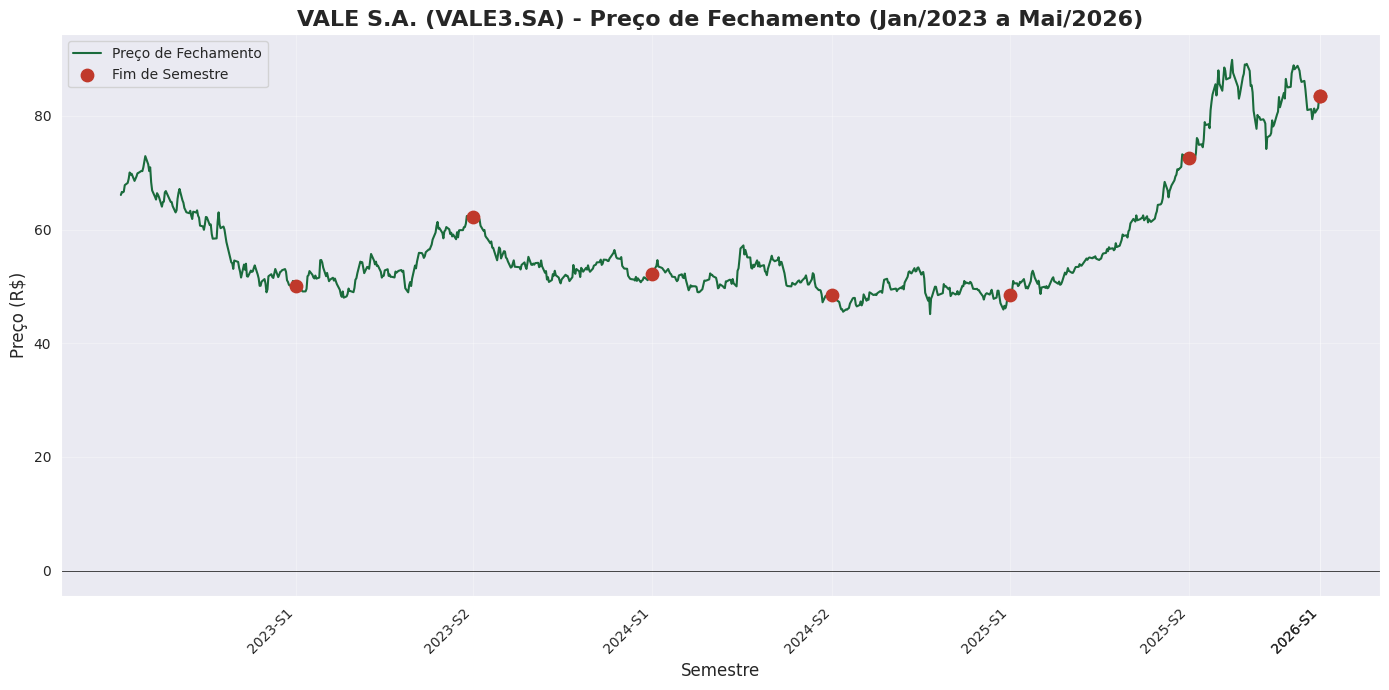


📊 TABELA RESUMO SEMESTRAL
 Ano Semestre  Abertura_R$  Fechamento_R$  Média_R$  Desvio_R$  Mínimo_R$  Máximo_R$  Retorno_%
2023       S1        66.08          50.04     59.96       7.04      48.95      72.91     -24.27
2023       S2        49.28          62.27     53.92       3.93      48.01      62.40      26.36
2024       S1        62.76          52.11     53.86       2.48      50.52      62.76     -16.96
2024       S2        52.98          48.51     51.81       2.00      47.20      57.20      -8.45
2025       S1        48.34          48.46     49.03       1.84      45.12      53.34       0.26
2025       S2        48.29          72.50     57.04       6.56      48.29      73.23      50.14
2026       S1        72.33          83.49     82.53       4.58      72.33      89.85      15.43

🎉 ANÁLISE CONCLUÍDA COM SUCESSO!

📈 RESUMO FINAL DO PERÍODO
Preço Inicial (jan/2023): R$ 66.08
Preço Final (mai/2026): R$ 83.49
Retorno Total no período: +26.35%
Volume Médio Diário: 24,182,592 ações


In [5]:
# =====================================================
# ANÁLISE DA VALE S.A. (VALE3) - JAN/2023 ATÉ MAI/2026
# =====================================================

!pip install yfinance pandas matplotlib seaborn -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

# ================== 1. BAIXAR DADOS ==================
ticker = "VALE3.SA"
start_date = "2023-01-01"
end_date = "2026-05-14"

print(f"📥 Baixando dados da {ticker} de {start_date} até {end_date}...")

df_vale = yf.download(ticker, start=start_date, end=end_date, progress=False)

print(f"✅ Dados carregados! Shape: {df_vale.shape}")
print(f"Colunas disponíveis: {list(df_vale.columns)}")

# Renomear colunas para português (apenas 5 colunas)
df_vale.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']

print(f"Período: {df_vale.index.min().date()} até {df_vale.index.max().date()}")

# ================== 2. 5 PRIMEIRAS E 5 ÚLTIMAS LINHAS ==================
print("\n" + "="*80)
print("📋 5 PRIMEIRAS LINHAS")
print("="*80)
print(df_vale[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].head().round(2))

print("\n" + "="*80)
print("📋 5 ÚLTIMAS LINHAS")
print("="*80)
print(df_vale[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].tail().round(2))

# ================== 3. MÉDIA ANUAL DO PREÇO DE FECHAMENTO ==================
df_vale['Ano'] = df_vale.index.year
media_anual = df_vale.groupby('Ano')['Fechamento'].mean()

print("\n" + "="*80)
print("📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, media in media_anual.items():
    print(f"{ano}: R$ {media:.2f}")

# ================== 4. DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO ==================
std_anual = df_vale.groupby('Ano')['Fechamento'].std()

print("\n" + "="*80)
print("📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, std in std_anual.items():
    print(f"{ano}: R$ {std:.2f}")

# ================== 5. RETORNO SEMESTRAL ==================
# Adicionar coluna de semestre
df_vale['Semestre'] = df_vale.index.quarter.map({1: 'S1', 2: 'S1', 3: 'S2', 4: 'S2'})
df_vale['Ano_Semestre'] = df_vale['Ano'].astype(str) + '_' + df_vale['Semestre']

# Calcular retorno semestral (último dia de cada semestre vs o anterior)
print("\n" + "="*80)
print("📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (%)")
print("="*80)

# Obter último dia de cada semestre
ultimo_dia_semestre = df_vale.groupby('Ano_Semestre').apply(lambda x: x.index.max())
retornos_semestrais = []

for i in range(len(ultimo_dia_semestre) - 1):
    sem_atual = ultimo_dia_semestre.index[i]
    sem_seguinte = ultimo_dia_semestre.index[i+1]

    fechamento_atual = df_vale.loc[ultimo_dia_semestre[i], 'Fechamento']
    fechamento_seguinte = df_vale.loc[ultimo_dia_semestre[i+1], 'Fechamento']

    retorno = ((fechamento_seguinte - fechamento_atual) / fechamento_atual) * 100
    sinal = "+" if retorno >= 0 else ""
    print(f"{sem_atual} → {sem_seguinte}: {sinal}{retorno:.2f}%")

    retornos_semestrais.append({
        'Período': f"{sem_atual} → {sem_seguinte}",
        'Retorno_%': retorno
    })

# ================== 6. GRÁFICO DE LINHA COM EIXO X SEMESTRAL ==================
# Criar pontos para cada semestre (último dia útil de cada semestre)
pontos_semestrais = []
labels_semestrais = []

# Definir os meses de fim de semestre: Junho (S1) e Dezembro (S2)
for ano in range(2023, 2027):
    for sem, mes in [('S1', 6), ('S2', 12)]:
        try:
            data_alvo = pd.Timestamp(f"{ano}-{mes:02d}-30")
            dados_semestre = df_vale[df_vale.index <= data_alvo]
            if not dados_semestre.empty:
                ultima_data = dados_semestre.index[-1]
                pontos_semestrais.append(ultima_data)
                labels_semestrais.append(f"{ano}-{sem}")
        except:
            pass

# Filtrar apenas pontos até maio/2026
pontos_semestrais = [p for p in pontos_semestrais if p <= pd.Timestamp("2026-05-14")]

# Criar o gráfico
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_vale.index, df_vale['Fechamento'], linewidth=1.5, color='#1A6B3C', label='Preço de Fechamento')

# Destacar pontos semestrais
if pontos_semestrais:
    valores_semestrais = df_vale.loc[pontos_semestrais, 'Fechamento']
    ax.scatter(pontos_semestrais, valores_semestrais, color='#C0392B', s=80, zorder=5, label='Fim de Semestre')

# Configurar eixo X com semestres
if pontos_semestrais:
    ax.set_xticks(pontos_semestrais)
    ax.set_xticklabels([f"{p.year}-{'S1' if p.month <= 6 else 'S2'}" for p in pontos_semestrais],
                       rotation=45, ha='right')

ax.set_title('VALE S.A. (VALE3.SA) - Preço de Fechamento (Jan/2023 a Mai/2026)', fontsize=16, fontweight='bold')
ax.set_xlabel('Semestre', fontsize=12)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# ================== 7. TABELA RESUMO SEMESTRAL ==================
print("\n" + "="*80)
print("📊 TABELA RESUMO SEMESTRAL")
print("="*80)

# Função para obter último dia de cada semestre
def get_ultimo_dia_semestre(df, ano, semestre):
    if semestre == 'S1':
        data_fim = pd.Timestamp(f"{ano}-06-30")
    else:
        data_fim = pd.Timestamp(f"{ano}-12-31")

    dados_sem = df[df.index <= data_fim]
    if not dados_sem.empty:
        ultima_data = dados_sem.index[-1]
        return ultima_data
    return None

tabela_semestral = []
for ano in range(2023, 2027):
    for sem in ['S1', 'S2']:
        ultima_data = get_ultimo_dia_semestre(df_vale, ano, sem)
        if ultima_data and ultima_data <= pd.Timestamp("2026-05-14"):
            dados_sem = df_vale[df_vale.index.year == ano]
            if sem == 'S1':
                dados_sem = dados_sem[dados_sem.index.month <= 6]
            else:
                dados_sem = dados_sem[dados_sem.index.month > 6]

            if not dados_sem.empty:
                abertura = dados_sem['Fechamento'].iloc[0]
                fechamento = dados_sem['Fechamento'].iloc[-1]
                media = dados_sem['Fechamento'].mean()
                desvio = dados_sem['Fechamento'].std()
                minimo = dados_sem['Fechamento'].min()
                maximo = dados_sem['Fechamento'].max()
                retorno = ((fechamento - abertura) / abertura) * 100

                tabela_semestral.append({
                    'Ano': ano,
                    'Semestre': sem,
                    'Abertura_R$': abertura,
                    'Fechamento_R$': fechamento,
                    'Média_R$': media,
                    'Desvio_R$': desvio,
                    'Mínimo_R$': minimo,
                    'Máximo_R$': maximo,
                    'Retorno_%': retorno
                })

df_tabela = pd.DataFrame(tabela_semestral)
print(df_tabela.to_string(index=False, float_format="%.2f"))

print("\n" + "="*80)
print("🎉 ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*80)

# Estatísticas adicionais finais
print("\n" + "="*80)
print("📈 RESUMO FINAL DO PERÍODO")
print("="*80)
preco_inicial = df_vale['Fechamento'].iloc[0]
preco_final = df_vale['Fechamento'].iloc[-1]
retorno_total = ((preco_final - preco_inicial) / preco_inicial) * 100
print(f"Preço Inicial (jan/2023): R$ {preco_inicial:.2f}")
print(f"Preço Final (mai/2026): R$ {preco_final:.2f}")
print(f"Retorno Total no período: {retorno_total:+.2f}%")
print(f"Volume Médio Diário: {df_vale['Volume'].mean():,.0f} ações")

# EXERCÍCIO: ANÁLISE COMPARATIVA DE AÇÕES BRASILEIRAS

## Contexto

Você é um analista financeiro e precisa avaliar o desempenho de 4 importantes empresas brasileiras no período de **janeiro de 2023 até 14 de maio de 2026**. As empresas e seus respectivos tickers são:

| Empresa | Ticker (Yahoo Finance) |
|---------|------------------------|
| Vale S.A. | VALE3.SA |
| Ambev S.A. | ABEV3.SA |
| Itaú Unibanco | ITUB4.SA |
| Banco do Brasil | BBAS3.SA |

## Objetivo

Para **cada uma das 4 empresas**, você deverá realizar as seguintes tarefas:

1. **Baixar os dados históricos** das ações no período solicitado utilizando a biblioteca `yfinance`

2. **Exibir as 5 primeiras e 5 últimas linhas** do DataFrame resultante (apenas as colunas de preços e volume)

3. **Calcular e exibir a média anual do preço de fechamento** para cada ano do período (2023, 2024, 2025 e 2026*)

4. **Calcular e exibir o desvio-padrão anual do preço de fechamento** para cada ano do período

5. **Calcular e exibir o retorno semestral** do preço de fechamento, mostrando a variação percentual entre semestres consecutivos (ex: 2023-S1 → 2023-S2, 2023-S2 → 2024-S1, etc.)

6. **Gerar um gráfico de linha do preço de fechamento** no período completo, com o eixo X rotulado apenas pelos semestres (ex: 2023-S1, 2023-S2, 2024-S1, etc.)